# Module 2c - From a Live Literature Search to a Dataset

Type a topic, pull the open-access papers for it, read their **full text**, and turn them into a clean table you can model. This first part does the harvest: **an OpenAlex filter you build on the website, pasted here, becomes a corpus of full-text PDFs downloaded and parsed automatically.**

**The live-demo flow**
1. On **openalex.org** search a topic and click filters until the page reads something like:
   *works where open access is (true) and year >= (2019) and title/abstract has (battery capacity mAh) and type is (article) and citation count >= (100)*
2. Copy the filter (the site shows the API query), paste it into the config cell below.
3. Run: the notebook pulls that corpus, downloads each open-access full-text PDF, and parses it.

No key and no login for any of this (OpenAlex is free; a courtesy email is optional).

## 0. Setup

In [1]:
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "requests", "pymupdf"])
import requests, re, io, time
print("ready")

ready


## 1. Paste your OpenAlex query (OQL)

Build the query on **openalex.org** by clicking filters. The builder writes it in **OQL** (OpenAlex Query Language), e.g.

```
works where citation count >= (100)
  and open access is (true)
  and year >= (2020)
  and title/abstract has (battery capacity and mAh)
  and type is (article)
```

**Copy that OQL and paste it below** - the notebook translates it into the OpenAlex API query. (It also accepts a full `api.openalex.org/works?...` URL or a raw filter string.)

In [2]:
import re
# ============ EDIT HERE (1 of 2): your OpenAlex query, built on openalex.org ============
# Paste the OQL exactly as the openalex.org builder writes it (or a URL / raw filter):
OQL = """
works where open access is (true)
  and year >= (2019)
  and title/abstract has (battery capacity and mAh)
  and type is (article)
"""

USE_CACHE = True   # True: read the shipped pre-crawled cache (offline, instant). False: crawl live.
N_PAPERS = 20                       # how many full-text papers to harvest (demo: 15-30)
MAILTO   = "ruiding@uchicago.edu"   # courtesy only, NOT a key; may be ""

# OQL display-name -> OpenAlex API filter key. Names whose key is just the snake_case
# of the name are handled by the fallback below, so any extra field a student adds
# on openalex.org keeps working; only genuinely unknown fields get a warning.
OQL_FIELDS = {
    "citation count": "cited_by_count", "cited by count": "cited_by_count",
    "year": "publication_year", "publication year": "publication_year",
    "open access": "open_access.is_oa", "is open access": "open_access.is_oa",
    "title/abstract": "title_and_abstract.search", "title and abstract": "title_and_abstract.search",
    "title": "title.search", "abstract": "abstract.search", "fulltext": "fulltext.search",
    "type": "type", "language": "language", "publication date": "publication_date",
    "is retracted": "is_retracted", "has doi": "has_doi",
    "has abstract": "has_abstract", "has fulltext": "has_fulltext",
}
SEARCHY = {"title_and_abstract.search", "title.search", "abstract.search", "fulltext.search"}

def parse_oql(text):
    """Translate OpenAlex OQL into an API filter. Also accepts a full openalex.org URL or raw filter."""
    t = text.strip()
    if "openalex.org" in t and "filter=" in t:
        from urllib.parse import urlparse, parse_qs, unquote
        return unquote(parse_qs(urlparse(t).query).get("filter", [""])[0])
    if ("where" not in t.lower()) and re.search(r"[a-z_]+\.[a-z_]+:", t):
        return t
    t = re.sub(r"^\s*works\s+where\s+", "", t, flags=re.I)
    parts, guessed = [], []
    for fld, op, val in re.findall(r"([a-zA-Z /_]+?)\s*(>=|<=|>|<|is not|is|has)\s*\(([^)]*)\)", t):
        fld = re.sub(r"^and\b\s*", "", fld.strip().lower()).strip(); val = val.strip()
        key = OQL_FIELDS.get(fld)
        if not key:                                   # fallback: name -> snake_case key
            key = re.sub(r"[ /]+", "_", fld); guessed.append(f"{fld} -> {key}")
        if key in SEARCHY:
            parts.append(f"{key}:" + re.sub(r"\s+and\s+", " ", val, flags=re.I)); continue
        v = val.lower() if val.lower() in ("true", "false") else val
        neg = "!" if op == "is not" else ""
        if op == ">=":   parts.append(f"{key}:>{int(val)-1}")
        elif op == "<=": parts.append(f"{key}:<{int(val)+1}")
        elif op == ">":  parts.append(f"{key}:>{val}")
        elif op == "<":  parts.append(f"{key}:<{val}")
        else:            parts.append(f"{key}:{neg}{v}")
    if guessed:
        print("  note: guessed these field keys (check OpenAlex docs if a query errors):", guessed)
    return ",".join(parts)

FILTER = parse_oql(OQL)
print("translated OQL -> OpenAlex filter:\n ", FILTER)

translated OQL -> OpenAlex filter:
  open_access.is_oa:true,publication_year:>2018,title_and_abstract.search:battery capacity mAh,type:article


## 2. Pull the corpus

Ask OpenAlex for works matching the filter, sorted by citations, and keep the ones that actually have a downloadable open-access PDF.

In [3]:
import pandas as pd, gzip, json, os
CACHE = "cache"
def openalex_count(filt, mail=""):
    p={"filter":filt,"per-page":1}
    if mail: p["mailto"]=mail
    return requests.get("https://api.openalex.org/works", params=p, timeout=45).json()["meta"]["count"]
def get_corpus(filt, n, mail=""):
    base,out,cur="https://api.openalex.org/works",[], "*"
    while len(out)<n:
        p={"filter":filt,"sort":"cited_by_count:desc","per-page":min(200,n-len(out)),"cursor":cur}
        if mail: p["mailto"]=mail
        j=requests.get(base,params=p,timeout=60).json(); res=j.get("results",[])
        if not res: break
        for w in res:
            loc=w.get("best_oa_location") or {}
            out.append(dict(title=(w.get("title") or "")[:140],year=w.get("publication_year"),
                venue=(loc.get("source") or {}).get("display_name"),cited=w.get("cited_by_count"),
                doi=(w.get("doi") or "").replace("https://doi.org/",""),pdf=loc.get("pdf_url") or ""))
            if len(out)>=n: break
        cur=j.get("meta",{}).get("next_cursor")
        if not cur: break
        time.sleep(0.2)
    return out

N_LIST = 200     # size of the LIVE paper list (ignored in cache mode)
if USE_CACHE and os.path.exists(f"{CACHE}/corpus_papers.csv"):
    papers = pd.read_csv(f"{CACHE}/corpus_papers.csv").fillna("")
    corpus = papers.to_dict("records")
    n_pdf  = sum(1 for p in corpus if p["pdf"])
    print(f"[cache] loaded {len(corpus)} papers from the shipped pre-crawl ({n_pdf} with an OA PDF). Offline, instant.")
else:
    TOTAL = openalex_count(FILTER, MAILTO)
    print(f"your query matches {TOTAL:,} papers in OpenAlex.\n")
    corpus = get_corpus(FILTER, min(N_LIST, TOTAL), MAILTO)
    n_pdf  = sum(1 for p in corpus if p["pdf"])
    print(f"built a list of {len(corpus)} papers (of {TOTAL:,} total); {n_pdf} have a downloadable OA PDF.")
    papers = pd.DataFrame(corpus)
papers.head(10)

[cache] loaded 1500 papers from the shipped pre-crawl (1456 with an OA PDF). Offline, instant.


,title,year,venue,cited,doi,pdf
0,Zinc anode-compatible in-situ solid electrolyt...,2019,Nature Communications,953,10.1038/s41467-019-13436-3,https://www.nature.com/articles/s41467-019-134...
1,Enhanced Potassium-Ion Storage of the 3D Carbo...,2020,Nano-Micro Letters,894,10.1007/s40820-020-00525-y,https://link.springer.com/content/pdf/10.1007/...
2,Revealing the closed pore formation of waste w...,2023,Nature Communications,809,10.1038/s41467-023-39637-5,https://www.nature.com/articles/s41467-023-396...
3,Scalable synthesis of ant-nest-like bulk porou...,2019,Nature Communications,784,10.1038/s41467-019-09510-5,https://www.nature.com/articles/s41467-019-095...
4,Dendritic Nanostructured Waste Copper Wires fo...,2019,Nano-Micro Letters,771,10.1007/s40820-019-0337-2,https://link.springer.com/content/pdf/10.1007/...
5,Conductive 2D metal-organic framework for high...,2019,Nature Communications,690,10.1038/s41467-019-12857-4,https://www.nature.com/articles/s41467-019-128...
6,Theoretical Calculation Guided Design of Singl...,2019,The Australian Nuclear Science and Technology ...,606,10.1021/acs.nanolett.9b04719,https://apo.ansto.gov.au/bitstreams/c00897af-b...
7,Steric Effect Tuned Ion Solvation Enabling Sta...,2021,OSTI OAI (U.S. Department of Energy Office of ...,596,10.1021/jacs.1c09006,https://www.osti.gov/servlets/purl/1878520
8,MgO‐Template Synthesis of Extremely High Capac...,2020,Angewandte Chemie International Edition,579,10.1002/anie.202013951,https://onlinelibrary.wiley.com/doi/pdfdirect/...
9,Tuning the Kinetics of Zinc‐Ion Insertion/Extr...,2020,OSTI OAI (U.S. Department of Energy Office of ...,557,10.1002/adma.202001113,https://www.osti.gov/servlets/purl/1756167


### Download the paper list

Save the matching-paper list and pull it to your computer with one click (a browser download dialog on Colab).

In [4]:
# save the paper list and offer a one-click download to your computer
papers.to_csv("corpus_papers.csv", index=False)
papers.to_json("corpus_papers.json", orient="records", force_ascii=False, indent=1)
print("saved: corpus_papers.csv  /  corpus_papers.json")
if "google.colab" in sys.modules:
    from google.colab import files
    files.download("corpus_papers.csv")     # <- this pops a browser "save file" dialog
    # files.download("corpus_papers.json")  # uncomment to grab the JSON too
else:
    print("(on Colab this pops a download dialog; locally the files are just written next to the notebook)")

saved: corpus_papers.csv  /  corpus_papers.json
(on Colab this pops a download dialog; locally the files are just written next to the notebook)


## 3. Download and parse the full text

Each open-access PDF is downloaded (with a normal browser header) and parsed to text. A publisher that blocks automated download (some return HTTP 403) is skipped with a note; the rest go through.

In [5]:
import gzip, json, os
N_FULLTEXT = 20   # LIVE only: how many PDFs to download+parse (the slow step). Cache mode loads all pre-crawled.
if USE_CACHE and os.path.exists(f"{CACHE}/fulltext.jsonl.gz"):
    texts=[json.loads(l) for l in gzip.open(f"{CACHE}/fulltext.jsonl.gz","rt")]
    print(f"[cache] loaded full text for {len(texts)} papers from the shipped pre-crawl. Offline, instant.")
else:
    import fitz
    UA={"User-Agent":"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"}
    def full_text(u):
        r=requests.get(u,headers=UA,timeout=60)
        if r.status_code!=200 or not (r.content[:4]==b"%PDF" or "pdf" in r.headers.get("content-type","")): return None
        return "\n".join(pg.get_text() for pg in fitz.open(stream=r.content,filetype="pdf"))[:60000]
    todo=[p for p in corpus if p["pdf"]][:N_FULLTEXT]
    print(f"downloading full text for {len(todo)} papers (raise N_FULLTEXT for more; PDFs are the slow part)\n")
    texts=[]
    for p in todo:
        try: t=full_text(p["pdf"])
        except Exception: t=None
        if t: texts.append({**p,"nchars":len(t),"text":t}); print(f"  ok  {len(t):6d} chars  {str(p['venue'])[:34]}")
        else: print(f"  skip (blocked/not a PDF)   {str(p['venue'])[:34]}")
        time.sleep(0.4)
    print(f"\nfull text obtained for {len(texts)}/{len(todo)} papers")
print(f"\n-> {len(texts)} full-text papers ready for extraction (next part).")

[cache] loaded full text for 337 papers from the shipped pre-crawl. Offline, instant.

-> 337 full-text papers ready for extraction (next part).


## 4. Extract a structured table from the full texts

An LLM reads each full text and returns one record: the main material, its chemistry family and electrode role, the headline **specific capacity (mAh/g)**, and the conditions (current density, C-rate, cycles, voltage). This is the same idea as Module 2a, now on battery papers. Cache mode loads the shipped table; live mode calls the model (paste a DeepSeek key).

In [6]:
import pandas as pd, os, json
DEEPSEEK_KEY = ""   # LIVE only: paste sk-... (DeepSeek). Cache mode needs no key.

# ============================  EDIT HERE (2 of 2): what to extract & model  ============================
# One definition drives BOTH the extraction prompt AND the model, so they can never fall out of sync.
DOMAIN      = "battery"                       # the kind of paper (used in the prompt)
TARGET      = "specific_capacity_mAh_g"       # the ONE numeric column to predict (goes LAST in the table)
CATEGORICAL = ["material_class", "chemistry_family", "electrode_role", "cell_type"]  # -> one-hot in the model
NUMERIC     = ["current_density_A_g", "C_rate", "cycle_number", "upper_cutoff_V",    # -> used as numbers
               "lower_cutoff_V", "temperature_C", "loading_mg_cm2", "first_cycle_CE_percent"]
HINTS = {   # a short hint per field to guide the LLM (allowed values / units)
    "material_class":   "sulfur|silicon|graphite|hard-carbon|NMC|NCA|LFP|LCO|V2O5|MnO2|Li-metal|Na-metal|Zn-metal|other",
    "chemistry_family": "Li-ion|Na-ion|K-ion|Zn-ion|Li-S|Li-metal|Mg-ion|Ca-ion|Al-ion|other",
    "electrode_role":   "cathode|anode|other",
    "cell_type":        "half-cell|full-cell|other",
    "specific_capacity_mAh_g": "reversible gravimetric specific capacity in mAh/g (not areal)",
    "current_density_A_g": "in A/g", "C_rate": "e.g. 0.2 for 0.2C", "cycle_number": "integer",
    "upper_cutoff_V": "V", "lower_cutoff_V": "V", "temperature_C": "deg C",
    "loading_mg_cm2": "mg/cm2", "first_cycle_CE_percent": "percent",
}
CLASS_THRESHOLD = 500   # classification: TARGET above this = "high", else "conventional"
# =======================================================================================================

COLS = CATEGORICAL + NUMERIC + [TARGET]        # target LAST -> the CSV drops straight into Module 1d
def build_prompt():
    fields = ",\n".join(f'  "{f}": <{HINTS.get(f, "value")}, or null>' for f in COLS)
    return (f"Extract ONE record from this {DOMAIN} paper's full text. Return ONLY a JSON object "
            f"(use null if a field is not stated):\n{{\n{fields}\n}}\n"
            f"Rules: use only values stated in the text; numeric fields must be plain numbers; output JSON only.")
PROMPT = build_prompt()

if USE_CACHE and os.path.exists("cache/battery_dataset.csv"):
    data = pd.read_csv("cache/battery_dataset.csv")
    print(f"[cache] loaded the extracted dataset: {len(data)} rows "
          f"({data[TARGET].notna().sum()} with a value for {TARGET}).")
else:
    from concurrent.futures import ThreadPoolExecutor
    def extract_one(p):
        body={"model":"deepseek-v4-flash","temperature":0,"thinking":{"type":"disabled"},"max_tokens":700,
              "response_format":{"type":"json_object"},
              "messages":[{"role":"user","content":PROMPT+"\n\nPAPER:\n"+p["text"][:45000]}]}
        try:
            r=requests.post("https://api.deepseek.com/chat/completions",
                headers={"Authorization":f"Bearer {DEEPSEEK_KEY}","Content-Type":"application/json"},
                data=json.dumps(body),timeout=120)
            return json.loads(r.json()["choices"][0]["message"]["content"])
        except Exception: return {}
    with ThreadPoolExecutor(max_workers=8) as ex:
        rows=list(ex.map(extract_one, texts))
    data=pd.DataFrame(rows).reindex(columns=COLS)
    print(f"extracted {len(data)} rows ({data[TARGET].notna().sum()} with a value for {TARGET}).")

print("\n--- the prompt built from your field definition (edit the block above to change it) ---")
print(PROMPT)
data.head(8)

[cache] loaded the extracted dataset: 295 rows (295 with a value for specific_capacity_mAh_g).

--- the prompt built from your field definition (edit the block above to change it) ---
Extract ONE record from this battery paper's full text. Return ONLY a JSON object (use null if a field is not stated):
{
  "material_class": <sulfur|silicon|graphite|hard-carbon|NMC|NCA|LFP|LCO|V2O5|MnO2|Li-metal|Na-metal|Zn-metal|other, or null>,
  "chemistry_family": <Li-ion|Na-ion|K-ion|Zn-ion|Li-S|Li-metal|Mg-ion|Ca-ion|Al-ion|other, or null>,
  "electrode_role": <cathode|anode|other, or null>,
  "cell_type": <half-cell|full-cell|other, or null>,
  "current_density_A_g": <in A/g, or null>,
  "C_rate": <e.g. 0.2 for 0.2C, or null>,
  "cycle_number": <integer, or null>,
  "upper_cutoff_V": <V, or null>,
  "lower_cutoff_V": <V, or null>,
  "temperature_C": <deg C, or null>,
  "loading_mg_cm2": <mg/cm2, or null>,
  "first_cycle_CE_percent": <percent, or null>,
  "specific_capacity_mAh_g": <reversible grav

,material_class,chemistry_family,electrode_role,cell_type,current_density_A_g,C_rate,cycle_number,upper_cutoff_V,lower_cutoff_V,temperature_C,loading_mg_cm2,first_cycle_CE_percent,specific_capacity_mAh_g
0,V2O5,Zn-ion,cathode,full-cell,0.60,NaN,800.0,NaN,NaN,NaN,NaN,NaN,110.0
1,silicon,Li-ion,anode,half-cell,NaN,0.5,1000.0,NaN,NaN,NaN,0.8,80.3,1271.0
2,hard-carbon,Na-ion,anode,half-cell,0.02,NaN,NaN,NaN,NaN,30.0,1.8,NaN,430.0
3,other,Zn-ion,cathode,full-cell,0.05,NaN,NaN,1.3,0.50,25.0,2.0,NaN,228.0
4,V2O5,Zn-ion,cathode,half-cell,1.00,NaN,1.0,1.6,0.20,25.0,NaN,NaN,398.8
5,silicon,Li-ion,anode,half-cell,NaN,NaN,1500.0,1.5,0.02,NaN,NaN,NaN,1500.0
6,other-oxide,Zn-ion,cathode,full-cell,1.00,NaN,1000.0,NaN,NaN,25.0,16.0,NaN,90.0
7,other,Na-ion,cathode,half-cell,0.02,NaN,100.0,3.6,1.00,NaN,NaN,NaN,452.0


### Download the dataset

One click to save the extracted table (`battery_dataset.csv`) to your computer.

In [7]:
data.to_csv("battery_dataset.csv", index=False)
data.reindex(columns=COLS).to_json("battery_dataset.json", orient="records", indent=1, force_ascii=False)
print("saved: battery_dataset.csv / battery_dataset.json")
if "google.colab" in sys.modules:
    from google.colab import files
    files.download("battery_dataset.csv")
else:
    print("(on Colab this pops a download dialog)")

saved: battery_dataset.csv / battery_dataset.json
(on Colab this pops a download dialog)


## 5. Close the loop: model the table (into Module 1)

The literature table now feeds the same kind of model as Module 1: one-hot the chemistry / electrode columns, keep the numeric conditions, and predict **specific capacity**. This is literature to dataset to model, end to end.

REGRESSION  predict specific_capacity_mAh_g (log10)   test R2 = 0.735   (n=295)


CLASSIFICATION  specific_capacity_mAh_g > 500 (high vs conventional)   test accuracy = 0.898  (baseline 0.64)


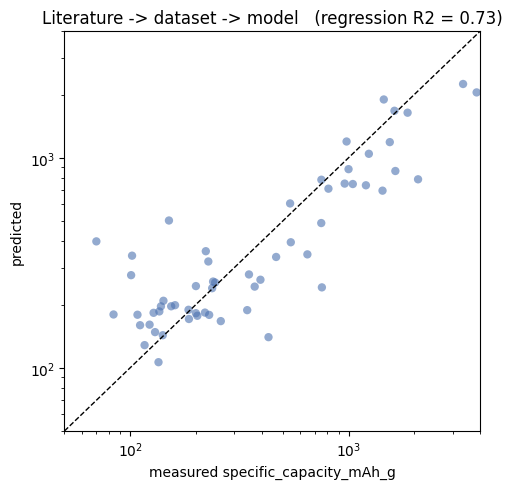

top drivers: ['chemistry_family_Li-S', 'electrode_role_anode', 'upper_cutoff_V', 'lower_cutoff_V', 'material_class_sulfur', 'cycle_number']


In [8]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, accuracy_score
SEED = 7   # one 80/20 split, same style as Modules 1a-1d

# features come straight from the field definition above -> prompt and model can't disagree
cats = [c for c in CATEGORICAL if c in data.columns]
nums = [c for c in NUMERIC if c in data.columns]
d = data[data[TARGET].notna()].copy()
tgt = pd.to_numeric(d[TARGET], errors="coerce")
d = d[tgt.between(1, 4000)]; tgt = tgt[tgt.between(1, 4000)]     # physical bound; drops rare parse outliers

X = pd.get_dummies(d[cats], columns=cats, dummy_na=True)
for n in nums: X[n] = pd.to_numeric(d[n], errors="coerce")
for n in [c for c in ("current_density_A_g", "cycle_number") if c in X]:
    X[n] = np.log1p(X[n].clip(lower=0))
X = X.fillna(X.median(numeric_only=True)).fillna(0.0)

# regression: predict the value (log10, since capacity spans ~60-3600)
y = np.log10(tgt.astype(float))
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf  = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1).fit(Xtr, ytr)
xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=0).fit(Xtr, ytr)
pred = (rf.predict(Xte) + xgb.predict(Xte)) / 2
R2 = r2_score(yte, pred)
print(f"REGRESSION  predict {TARGET} (log10)   test R2 = {R2:.3f}   (n={len(d)})")

# classification: high vs conventional at CLASS_THRESHOLD
yc = (tgt > CLASS_THRESHOLD).astype(int)
Xa,Xb,ya,yb = train_test_split(X, yc, test_size=0.2, random_state=SEED, stratify=yc)
acc = accuracy_score(yb, RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1).fit(Xa,ya).predict(Xb))
print(f"CLASSIFICATION  {TARGET} > {CLASS_THRESHOLD} (high vs conventional)   test accuracy = {acc:.3f}  "
      f"(baseline {yb.value_counts(normalize=True).max():.2f})")

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(10**yte, 10**pred, alpha=.6, color="#4C72B0", edgecolor="none")
lim=[50,4000]; ax.plot(lim,lim,"k--",lw=1)
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel=f"measured {TARGET}", ylabel="predicted",
       title=f"Literature -> dataset -> model   (regression R2 = {R2:.2f})")
os.makedirs("figures", exist_ok=True); fig.tight_layout(); fig.savefig("figures/2c_capacity_parity.png", dpi=140); plt.show()
print("top drivers:", list(pd.Series(rf.feature_importances_, index=X.columns).nlargest(6).index))

## What you built

A closed loop, all from a topic: **OQL search -> open-access corpus -> full text -> an LLM-extracted table -> a model of specific capacity.** Change the OQL to your own field and the whole pipeline follows. The pre-crawled cache lets it run offline in seconds; live mode does it for real with a DeepSeek key.